In [1]:
import pandas as pd
import numpy as np
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('rslp')

# Identificação
ru_3671819 = "Fabiana A. D'Agostino da Silva"
print("Bibliotecas carregadas com sucesso!")
print(f"Aluna: {ru_3671819}")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/fabianadagostino/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package rslp to
[nltk_data]     /home/fabianadagostino/nltk_data...


Bibliotecas carregadas com sucesso!
Aluna: Fabiana A. D'Agostino da Silva


[nltk_data]   Unzipping stemmers/rslp.zip.


In [2]:
# Carregando o dataset
df = pd.read_csv('pre-processed.csv', encoding='utf-8')
print(df.shape)
print(df['label'].value_counts())
print(df.head(2))

(7200, 3)
label
fake    3600
true    3600
Name: count, dtype: int64
   index label                                  preprocessed_news
0      0  fake  katia abreu diz vai colocar expulsao moldura n...
1      1  fake  ray peita bolsonaro conservador fake entrevist...


In [3]:
# Verificando tamanho médio dos textos
df['num_palavras'] = df['preprocessed_news'].apply(lambda x: len(str(x).split()))

print("Tamanho médio por categoria:")
print(df.groupby('label')['num_palavras'].mean())
print("\nTamanho mínimo e máximo:")
print(df.groupby('label')['num_palavras'].agg(['min', 'max']))

Tamanho médio por categoria:
label
fake    107.940833
true    624.935556
Name: num_palavras, dtype: float64

Tamanho mínimo e máximo:
       min   max
label           
fake     5  1220
true    13  4229


In [ ]:
# Normalizando o tamanho dos textos
tamanho_fake = int(df[df['label'] == 'fake']['num_palavras'].mean())
print(f"Truncando textos TRUE para {tamanho_fake} palavras")

def truncar_texto(texto, max_palavras):
    palavras = str(texto).split()
    return ' '.join(palavras[:max_palavras])

df['texto_normalizado'] = df.apply(
    lambda row: truncar_texto(row['preprocessed_news'], tamanho_fake)
    if row['label'] == 'true'
    else str(row['preprocessed_news']),
    axis=1
)

# Verificando resultado
df['num_palavras_norm'] = df['texto_normalizado'].apply(lambda x: len(str(x).split()))
print("\nTamanho médio após normalização:")
print(df.groupby('label')['num_palavras_norm'].mean())

Truncando textos TRUE para 107 palavras

Tamanho médio após normalização:
label
fake    107.940833
true    106.761389
Name: num_palavras_norm, dtype: float64


In [5]:
# Célula 5 — Pré-processamento com NLTK
stop_words = set(stopwords.words('portuguese'))
stemmer = RSLPStemmer()

def preprocessar(texto):
    # Minúsculas
    texto = texto.lower()
    # Remove caracteres especiais e números
    texto = re.sub(r'[^a-záéíóúàâêôãõç\s]', '', texto)
    # Separa em palavras
    palavras = texto.split()
    # Remove stopwords (palavras sem significado: "de", "que", "o"...)
    palavras = [p for p in palavras if p not in stop_words]
    # Stemming (reduz ao radical: "correndo" → "corr")
    palavras = [stemmer.stem(p) for p in palavras]
    return ' '.join(palavras)

print("Processando textos... aguarde.")
df['texto_limpo'] = df['texto_normalizado'].apply(preprocessar)
print("Concluído!")
print("\nExemplo antes:", df['texto_normalizado'][0][:100])
print("Exemplo depois:", df['texto_limpo'][0][:100])

Processando textos... aguarde.
Concluído!

Exemplo antes: katia abreu diz vai colocar expulsao moldura nao reclamar senadora katia abreu disse expulsao pmdb r
Exemplo depois: kat abr diz vai coloc expulsa mold nao reclam sen kat abr diss expulsa pmdb result aca cupul atual l


In [6]:
# TF-IDF e divisão treino/teste
X = df['texto_limpo']
y = df['label']

# 75% treino, 25% teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# TF-IDF com unigramas, bigramas e trigramas
tfidf_3671819 = TfidfVectorizer(ngram_range=(1, 3), max_features=50000)

X_treino_tfidf = tfidf_3671819.fit_transform(X_treino)
X_teste_tfidf  = tfidf_3671819.transform(X_teste)

vocabulario = tfidf_3671819.vocabulary_
unigramas = [t for t in vocabulario if len(t.split()) == 1]
bigramas  = [t for t in vocabulario if len(t.split()) == 2]
trigramas = [t for t in vocabulario if len(t.split()) == 3]

print(f"Treino: {X_treino_tfidf.shape[0]} textos")
print(f"Teste:  {X_teste_tfidf.shape[0]} textos")
print(f"Unigramas: {len(unigramas)}")
print(f"Bigramas:  {len(bigramas)}")
print(f"Trigramas: {len(trigramas)}")

Treino: 5400 textos
Teste:  1800 textos
Unigramas: 9456
Bigramas:  32213
Trigramas: 8331


In [7]:
# Treinar e avaliar o modelo
modelo_3671819 = LogisticRegression(max_iter=1000)
modelo_3671819.fit(X_treino_tfidf, y_treino)

predicoes = modelo_3671819.predict(X_teste_tfidf)
acuracia = accuracy_score(y_teste, predicoes)

print(f"Acurácia do modelo: {acuracia:.2%}")

Acurácia do modelo: 89.11%


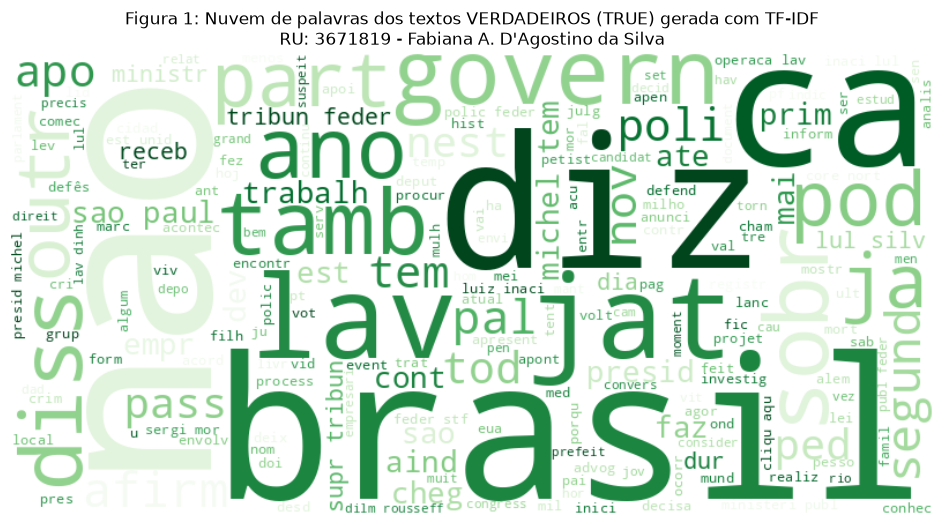

Imagem salva: nuvem_true.png


In [8]:
# Célula 8 — Nuvem de palavras textos VERDADEIROS (Questão 01)
textos_true = ' '.join(df[df['label'] == 'true']['texto_limpo'])
textos_true += ' RU3671819 ' * 50  # identificação pessoal na nuvem

nuvem_true = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Greens',
    max_words=200
).generate(textos_true)

plt.figure(figsize=(12, 6))
plt.imshow(nuvem_true, interpolation='bilinear')
plt.axis('off')
plt.title('Figura 1: Nuvem de palavras dos textos VERDADEIROS (TRUE) gerada com TF-IDF\nRU: 3671819 - Fabiana A. D\'Agostino da Silva')
plt.savefig('nuvem_true.png', dpi=150, bbox_inches='tight')
plt.show()
print("Imagem salva: nuvem_true.png")

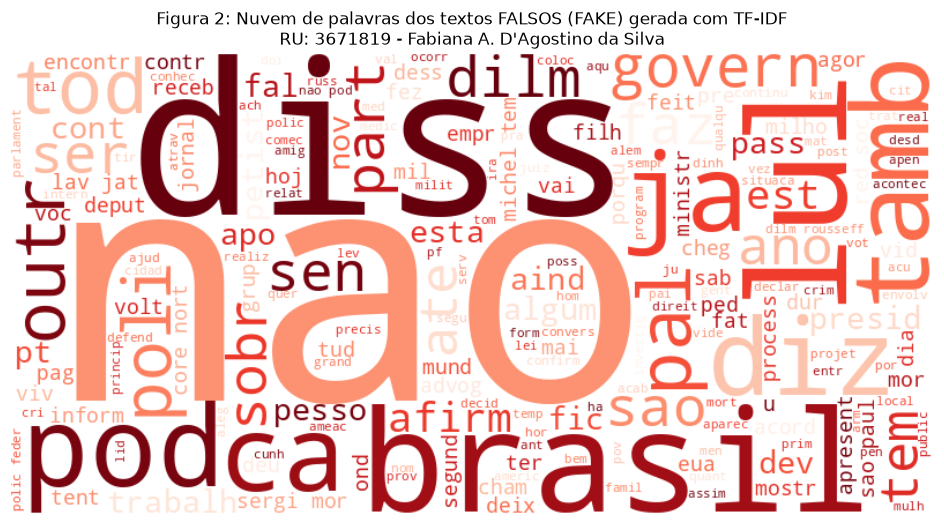

Imagem salva: nuvem_fake.png


In [9]:
# Nuvem de palavras textos falsos
textos_fake = ' '.join(df[df['label'] == 'fake']['texto_limpo'])
textos_fake += ' RU3671819 ' * 50  # identificação pessoal na nuvem

nuvem_fake = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    max_words=200
).generate(textos_fake)

plt.figure(figsize=(12, 6))
plt.imshow(nuvem_fake, interpolation='bilinear')
plt.axis('off')
plt.title('Figura 2: Nuvem de palavras dos textos FALSOS (FAKE) gerada com TF-IDF\nRU: 3671819 - Fabiana A. D\'Agostino da Silva')
plt.savefig('nuvem_fake.png', dpi=150, bbox_inches='tight')
plt.show()
print("Imagem salva: nuvem_fake.png")